# Optional Bridge: A Real Local LLM and SEC EDGAR

**Extension:** beyond the 17 core labs  
**Runtime:** 2 minutes offline; model download and inference are opt-in  
**Credentials:** none for the default run; SEC requires a declared contact user agent

This notebook closes the gap between controlled teaching fixtures and external systems
without weakening the release contract. Its default execution performs **no network
access**. It demonstrates the full adapter and provenance path against a synthetic
SEC-shaped payload, then exposes two explicit opt-in gates:

1. local inference with
   [`HuggingFaceTB/SmolLM2-360M-Instruct`](https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct);
2. public company-facts ingestion from the
   [SEC EDGAR APIs](https://www.sec.gov/search-filings/edgar-application-programming-interfaces).

Neither path grants execution authority. External text remains a proposal, and public
data remain inadmissible until their timing and provenance checks pass.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/17_optional_real_model_and_sec.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/17_optional_real_model_and_sec.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

By the end of this extension, you will be able to:

1. make model downloads and public-data access opt-in rather than accidental;
2. record model, revision, prompt, and deterministic decoding metadata;
3. preserve raw SEC response hashes and retrieval timestamps;
4. build a conservative point-in-time view of amended company facts; and
5. keep model output behind numerical, citation, policy, and human-review gates.


In [2]:
from copy import deepcopy
from dataclasses import asdict
from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab.integrations import (
    SecSnapshot,
    company_fact_observations,
    fetch_sec_company_facts,
    generate_with_transformers,
)
from finllm_lab.plotting import COLORS, finish, set_finance_theme

set_finance_theme()
RUN_REAL_MODEL = os.getenv("FINLLM_RUN_REAL_MODEL", "0") == "1"
RUN_SEC = os.getenv("FINLLM_RUN_SEC", "0") == "1"

pd.DataFrame(
    [
        {
            "adapter": "local Transformers model",
            "enabled": RUN_REAL_MODEL,
            "default": "disabled",
            "side_effect": "downloads model files when first enabled",
        },
        {
            "adapter": "SEC company facts",
            "enabled": RUN_SEC,
            "default": "disabled",
            "side_effect": "one declared GET request when enabled",
        },
    ]
)


,adapter,enabled,default,side_effect
0,local Transformers model,False,disabled,downloads model files when first enabled
1,SEC company facts,False,disabled,one declared GET request when enabled


## 1. Real-model inference is a proposal, not a benchmark result

To enable the pinned optional software stack:

```bash
python -m pip install -e ".[extensions]"
FINLLM_RUN_REAL_MODEL=1 jupyter lab
```

The example uses greedy decoding and records the resolved model revision when the
backend exposes it. The repository deliberately does not ship a generated answer from
an unrecorded download. A release-grade experiment should replace `main` with an
immutable model commit and retain the resulting model card.


In [3]:
calls = pd.read_csv(ROOT / "data" / "earnings_calls.csv")
example = calls.query("ticker == 'ACME' and period == '2026Q1'").iloc[0]
evidence_id = example["document_id"]
prompt = f"""
You are drafting a financial research note from one supplied evidence record.
Use only the record. Write two short sentences and end each sentence with
the citation [{evidence_id}]. Do not recommend a trade.

EVIDENCE {evidence_id}
{example["text"]}
""".strip()

model_id = "HuggingFaceTB/SmolLM2-360M-Instruct"
requested_revision = os.getenv("FINLLM_MODEL_REVISION", "main")
if RUN_REAL_MODEL:
    generation = generate_with_transformers(
        prompt,
        model_id=model_id,
        revision=requested_revision,
        max_new_tokens=120,
        enabled=True,
    )
    model_status = "RAN — OUTPUT REQUIRES REVIEW"
else:
    generation = None
    model_status = "SKIPPED_BY_DESIGN"

pd.DataFrame(
    [
        {
            "status": model_status,
            "model": model_id,
            "requested_revision": requested_revision,
            "prompt_sha256": hashlib.sha256(prompt.encode()).hexdigest()[:16],
            "response_preview": generation.response[:180] if generation else "No model output shipped.",
        }
    ]
)


,status,model,requested_revision,prompt_sha256,response_preview
0,SKIPPED_BY_DESIGN,HuggingFaceTB/SmolLM2-360M-Instruct,main,9c29a38e24007549,No model output shipped.


In [4]:
if generation is None:
    model_review = {
        "run_status": "SKIPPED_NOT_EVALUATED",
        "citation_present": False,
        "trade_recommendation_prohibited": True,
        "automatic_release": False,
        "next_step": "Enable intentionally, pin a revision, evaluate, then request human review.",
    }
else:
    response_lower = generation.response.lower()
    model_review = {
        "run_status": "HUMAN_REVIEW_REQUIRED",
        "citation_present": f"[{evidence_id}]" in generation.response,
        "trade_recommendation_prohibited": not any(
            phrase in response_lower
            for phrase in ("buy ", "sell ", "long ", "short ")
        ),
        "automatic_release": False,
        "next_step": "Run numerical and faithfulness checks; a human owns release.",
        "generation_record": asdict(generation),
    }
model_review


{'automatic_release': False,
 'citation_present': False,
 'next_step': 'Enable intentionally, pin a revision, evaluate, then request human review.',
 'run_status': 'SKIPPED_NOT_EVALUATED',
 'trade_recommendation_prohibited': True}

## 2. SEC data: raw snapshot first, analytical table second

SEC Company Facts does not expose an intraday acceptance timestamp for every fact.
This adapter therefore assigns a conservative availability time of **06:00 UTC on the
day after the filing date**. Amendments replace prior values only after the amendment
itself is admissible. The raw response hash, retrieval time, accession number, and
source URL remain attached to every analytical observation. A snapshot retrieved after
a decision time is rejected, so historical evaluation requires archived snapshots.

The following payload is synthetic and exists only to execute and test the contract
offline.


In [5]:
pre_amendment_payload = {
    "cik": 9999999999,
    "entityName": "Fictional SEC-Shape Example",
    "facts": {
        "us-gaap": {
            "Revenues": {
                "units": {
                    "USD": [
                        {
                            "accn": "0000000000-26-000001",
                            "end": "2025-12-31",
                            "filed": "2026-02-10",
                            "form": "10-K",
                            "val": 1_000_000_000,
                            "fy": 2025,
                            "fp": "FY",
                        },
                    ]
                }
            }
        }
    },
}
post_amendment_payload = deepcopy(pre_amendment_payload)
post_amendment_payload["facts"]["us-gaap"]["Revenues"]["units"]["USD"].append(
    {
        "accn": "0000000000-26-000002",
        "end": "2025-12-31",
        "filed": "2026-03-01",
        "form": "10-K/A",
        "val": 1_020_000_000,
        "fy": 2025,
        "fp": "FY",
    }
)
pre_amendment_raw = json.dumps(pre_amendment_payload, sort_keys=True).encode()
post_amendment_raw = json.dumps(post_amendment_payload, sort_keys=True).encode()
pre_amendment_snapshot = SecSnapshot(
    cik="9999999999",
    source_url="synthetic://sec-companyfacts-contract-test",
    retrieved_at=datetime(2026, 2, 11, 12, tzinfo=timezone.utc),
    raw_sha256=hashlib.sha256(pre_amendment_raw).hexdigest(),
    payload=pre_amendment_payload,
)
post_amendment_snapshot = SecSnapshot(
    cik="9999999999",
    source_url="synthetic://sec-companyfacts-contract-test",
    retrieved_at=datetime(2026, 3, 2, 12, tzinfo=timezone.utc),
    raw_sha256=hashlib.sha256(post_amendment_raw).hexdigest(),
    payload=post_amendment_payload,
)

before_amendment = company_fact_observations(
    pre_amendment_snapshot,
    taxonomy="us-gaap",
    concept="Revenues",
    unit="USD",
    decision_time=datetime(2026, 2, 20, tzinfo=timezone.utc),
)
after_amendment = company_fact_observations(
    post_amendment_snapshot,
    taxonomy="us-gaap",
    concept="Revenues",
    unit="USD",
    decision_time=datetime(2026, 3, 3, tzinfo=timezone.utc),
)
pd.DataFrame(
    [
        {
            "decision_time": "2026-02-20",
            "admissible_value_usd": before_amendment[0]["value"],
            "accession": before_amendment[0]["accession"],
        },
        {
            "decision_time": "2026-03-03",
            "admissible_value_usd": after_amendment[0]["value"],
            "accession": after_amendment[0]["accession"],
        },
    ]
)


,decision_time,admissible_value_usd,accession
0,2026-02-20,1000000000,0000000000-26-000001
1,2026-03-03,1020000000,0000000000-26-000002


## 3. Optional live SEC request

The SEC APIs require no authentication token, but automated access must declare a
descriptive user agent with a monitored email. Set both variables before launching:

```bash
export FINLLM_RUN_SEC=1
export SEC_USER_AGENT="Your Organization research@example.org"
```

The example CIK is used only when that explicit gate is enabled. The release itself
contains no real-company response or cached public-data snapshot.


In [6]:
if RUN_SEC:
    declared_user_agent = os.getenv("SEC_USER_AGENT", "")
    live_snapshot = fetch_sec_company_facts(
        "0000320193",
        user_agent=declared_user_agent,
        enabled=True,
    )
    live_observations = company_fact_observations(
        live_snapshot,
        taxonomy="us-gaap",
        concept="RevenueFromContractWithCustomerExcludingAssessedTax",
        unit="USD",
        decision_time=datetime.now(timezone.utc),
    )
    sec_status = {
        "status": "RAN — PUBLIC DATA NOT SHIPPED",
        "snapshot_sha256": live_snapshot.raw_sha256,
        "retrieved_at": live_snapshot.retrieved_at.isoformat(),
        "admissible_observations": len(live_observations),
    }
else:
    sec_status = {
        "status": "SKIPPED_BY_DESIGN",
        "snapshot_sha256": None,
        "retrieved_at": None,
        "admissible_observations": 0,
    }
sec_status


{'admissible_observations': 0,
 'retrieved_at': None,
 'snapshot_sha256': None,
 'status': 'SKIPPED_BY_DESIGN'}

## 4. The external-system control surface

Enabling an adapter changes the evidence source, not the governance architecture.
The model still cannot release its own prose, and a public observation still cannot
enter a backtest before its conservative availability time.


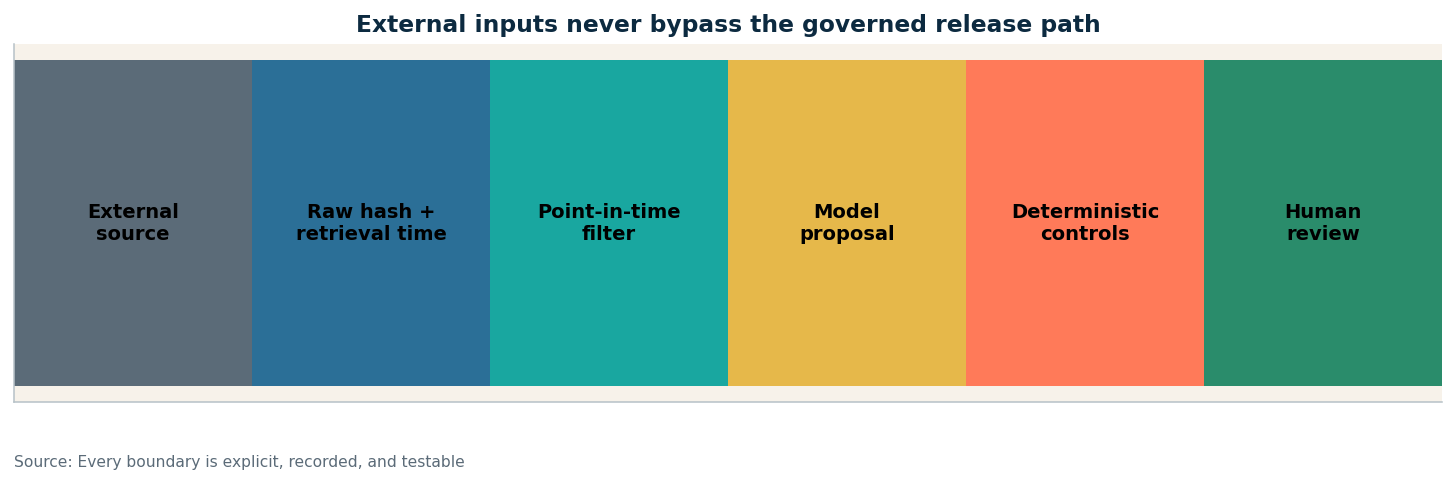

In [7]:
stages = [
    "External\nsource",
    "Raw hash +\nretrieval time",
    "Point-in-time\nfilter",
    "Model\nproposal",
    "Deterministic\ncontrols",
    "Human\nreview",
]
stage_colors = [
    COLORS["slate"],
    COLORS["blue"],
    COLORS["teal"],
    COLORS["gold"],
    COLORS["coral"],
    COLORS["green"],
]
fig, ax = plt.subplots(figsize=(10.5, 3.6))
ax.barh(["optional bridge"] * len(stages), [1] * len(stages), left=range(len(stages)), color=stage_colors)
for index, label in enumerate(stages):
    ax.text(index + 0.5, 0, label, ha="center", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, len(stages))
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("External inputs never bypass the governed release path")
finish(ax, "Every boundary is explicit, recorded, and testable")
plt.tight_layout()


## Release contract and exercises

The executed artifact is healthy only when both optional adapters report
`SKIPPED_BY_DESIGN`. That proves the default build made no unrecorded external call.

**Exercises**

1. Run the model adapter with a pinned immutable revision and complete
   `model_cards/template.md`.
2. Add a faithfulness benchmark with at least 30 held-out questions and Wilson
   intervals.
3. Replace the conservative next-day SEC timestamp with accession-level acceptance
   times from a separately snapshotted submissions feed.
4. Demonstrate that an amendment changes a signal only after its own availability
   time.
5. Add a second model backend without changing the deterministic release gate.
